In [2]:
import pandas as pd
import pandas_ta as ta
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display as dp
import os

In [3]:
# 파일 리스트
file_paths = [
    'AMD.csv', 'S&P500 ETF.csv', '나스닥 ETF.csv', '마이크로소프트.csv',
    '메타.csv', '아마존.csv', '알파벳.csv', '애플.csv', '엔비디아.csv', '테슬라.csv'
]

df_dict = {}
for path in file_paths:
    df = pd.read_csv(f'/home/nshawny/AI project 2/personal_data/stock/overseas/{path}')
    df['Name'] = os.path.splitext(path)[0]  # 종목명 저장
    df_dict[path] = df

In [4]:
for name, df in df_dict.items():
    df['High_Low_Range'] = (df['High'] - df['Low']) / df['Close']
    df['Volatility_20'] = df['Close'].rolling(window=20).std()

In [5]:
summary = []
for name, df in df_dict.items():
    mean_vol = df['High_Low_Range'].tail(252).mean()
    summary.append((name, mean_vol))

summary.sort(key=lambda x: x[1])
print(summary[:10])  # 변동성 낮은 종목 3개 추출


[('S&P500 ETF.csv', 0.012450165171429398), ('나스닥 ETF.csv', 0.016445229149056814), ('마이크로소프트.csv', 0.018592277294242853), ('애플.csv', 0.02247099586858519), ('알파벳.csv', 0.023705087796570934), ('아마존.csv', 0.025212134480420464), ('메타.csv', 0.028385138941625313), ('AMD.csv', 0.03745052706811772), ('엔비디아.csv', 0.041289971312777306), ('테슬라.csv', 0.051245623100938345)]


In [6]:
summary_5 = []
for name, df in df_dict.items():
    mean_vol = df['High_Low_Range'].tail(1224).mean()
    summary_5.append((name, mean_vol))

summary_5.sort(key=lambda x: x[1])
print(summary_5[:10])  # 변동성 낮은 종목 3개 추출


[('S&P500 ETF.csv', 0.012400106979249065), ('나스닥 ETF.csv', 0.01681316543199947), ('마이크로소프트.csv', 0.020104899745724526), ('애플.csv', 0.02205870617813812), ('알파벳.csv', 0.02288060126400919), ('아마존.csv', 0.02610821110624658), ('메타.csv', 0.029101974511802207), ('엔비디아.csv', 0.039290974576591704), ('AMD.csv', 0.03970721530000223), ('테슬라.csv', 0.04711718903706812)]


In [ ]:
volatility_summary = []

for name, df in df_dict.items():
    mean_vol20 = df['Volatility_20'].tail(252).mean()
    volatility_summary.append((name, mean_vol20))

# 낮은 순으로 정렬
volatility_summary.sort(key=lambda x: x[1])

# 결과 출력
print('📊 Volatility_20 기반 최근 1년 평균 랭킹')
for rank, (name, mean_val) in enumerate(volatility_summary, 1):
    print(f'{rank}. {name}: {mean_val:.4f}')


📊 Volatility_20 기반 최근 1년 평균 랭킹
1. 알파벳.csv: 5.4338
2. 엔비디아.csv: 6.8177
3. 애플.csv: 6.9141
4. AMD.csv: 6.9386
5. 아마존.csv: 6.9937
6. S&P500 ETF.csv: 10.1182
7. 마이크로소프트.csv: 11.1339
8. 나스닥 ETF.csv: 11.7046
9. 메타.csv: 22.8824
10. 테슬라.csv: 22.9779


In [9]:
volatility_summary = []

for name, df in df_dict.items():
    mean_vol20 = df['Volatility_20'].tail(1225).mean()
    volatility_summary.append((name, mean_vol20))

# 낮은 순으로 정렬
volatility_summary.sort(key=lambda x: x[1])

# 결과 출력
print('📊 Volatility_20 기반 최근 5년 평균 랭킹')
for rank, (name, mean_val) in enumerate(volatility_summary, 1):
    print(f'{rank}. {name}: {mean_val:.4f}')


📊 Volatility_20 기반 최근 5년 평균 랭킹
1. 엔비디아.csv: 2.7665
2. 알파벳.csv: 3.9388
3. 애플.csv: 5.0184
4. 아마존.csv: 5.3389
5. AMD.csv: 5.8680
6. S&P500 ETF.csv: 7.5619
7. 마이크로소프트.csv: 8.1987
8. 나스닥 ETF.csv: 8.5137
9. 메타.csv: 13.4729
10. 테슬라.csv: 16.4097


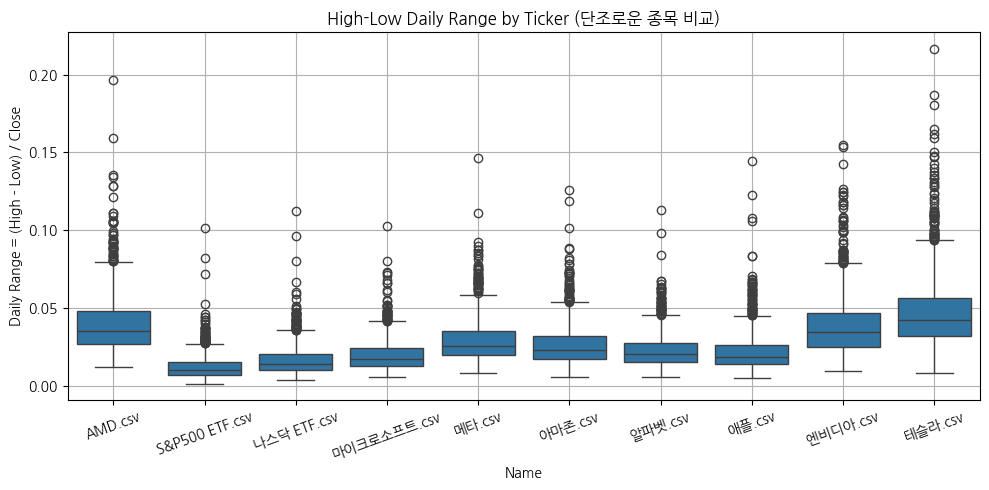

In [16]:
plt.rcParams['font.family'] = 'NanumGothic'
# 마이너스 기호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False
# 3개 종목만 필터
# selected_names = ['S&P500 ETF.csv', '나스닥 ETF.csv', '마이크로소프트.csv']

# 하나의 df로 통합
df_all = pd.concat([df.assign(Name=name) for name, df in df_dict.items()])


# 박스플롯
plt.figure(figsize=(10, 5))
sns.boxplot(data=df_all, x='Name', y='High_Low_Range')
plt.title("High-Low Daily Range by Ticker (단조로운 종목 비교)")
plt.ylabel("Daily Range = (High - Low) / Close")
plt.xticks(rotation=20)
plt.grid(True)
plt.tight_layout()
plt.show()


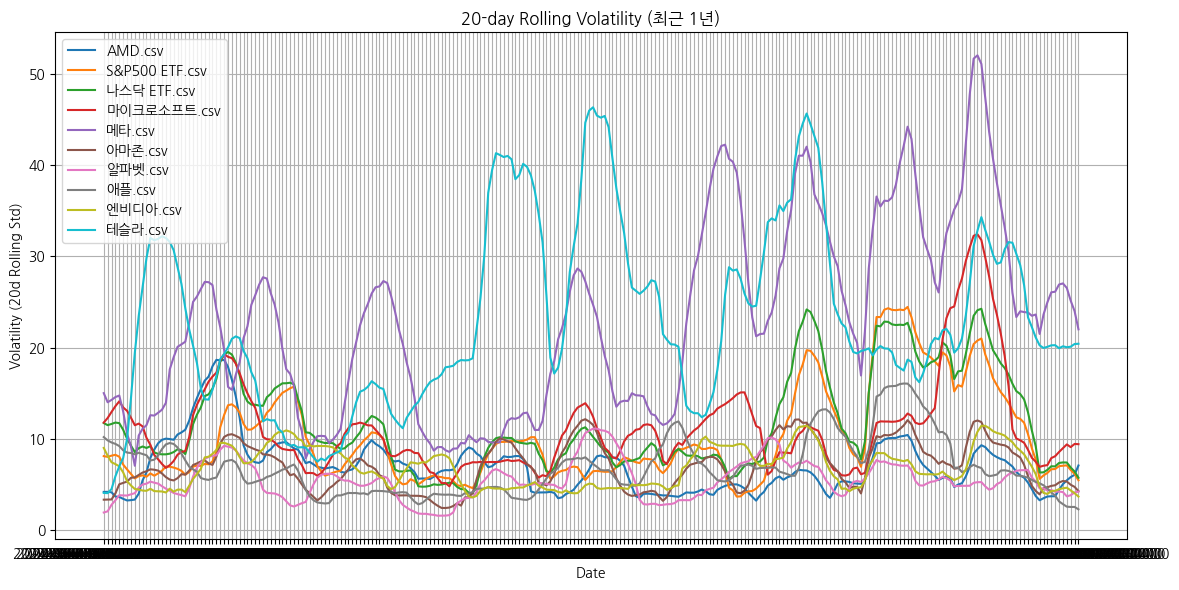

In [14]:
plt.figure(figsize=(12, 6))
for name, df in df_dict.items():
    df = df_dict[name]
    plt.plot(df['Date'][-252:], df['Volatility_20'][-252:], label=name)

plt.title("20-day Rolling Volatility (최근 1년)")
plt.xlabel("Date")
plt.ylabel("Volatility (20d Rolling Std)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


<Axes: >

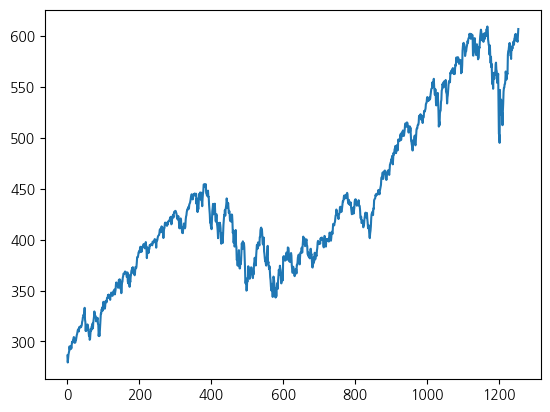

In [12]:
df_dict['S&P500 ETF.csv'].Close.plot()

<Axes: >

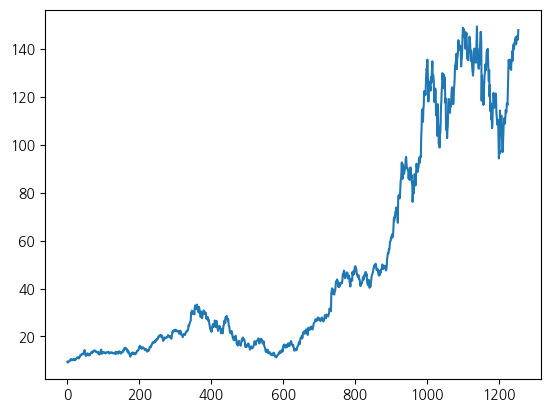

In [13]:
df_dict['엔비디아.csv'].Close.plot()

엔비디아, 애플, 아마존